#### Importing Processed top 20 RF features and PCA 10 features for further analysis and modeling. 

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style('whitegrid')

In [2]:
BASE_DIR = "../../Dataset/"

In [3]:
rf_data = pd.read_parquet(os.path.join(BASE_DIR, "rf_top_20.parquet"))
pca_data = pd.read_parquet(os.path.join(BASE_DIR, "pca_10_df.parquet"))

rf_data.head()

,bwd packet length std,avg bwd segment size,bwd packet length mean,packet length variance,bwd packet length max,packet length std,bwd packets length total,avg packet size,fwd iat std,packet length mean,...,total fwd packets,bwd packets/s,subflow bwd bytes,flow packets/s,subflow fwd packets,flow iat max,fwd iat max,fwd packets length total,subflow bwd packets,label
0,0.000000,0.0,0.0,0.000000,0,0.000000,0,9.00000,0.000000,6.000000,...,2,0.000000,0,5.000000e+05,2,4,4,12,0,Benign
1,0.000000,0.0,0.0,0.000000,0,0.000000,0,9.00000,0.000000,6.000000,...,2,0.000000,0,2.000000e+06,2,1,1,12,0,Benign
2,0.000000,0.0,0.0,0.000000,0,0.000000,0,9.00000,0.000000,6.000000,...,2,0.000000,0,6.666667e+05,2,3,3,12,0,Benign
3,0.000000,0.0,0.0,0.000000,0,0.000000,0,9.00000,0.000000,6.000000,...,2,0.000000,0,2.000000e+06,2,1,1,12,0,Benign
4,119.511505,103.5,103.5,11562.151367,207,107.527443,414,81.63636,177.089523,74.833336,...,7,6568.144531,414,1.806240e+04,7,381,460,484,4,Benign


In [4]:
val_counts = rf_data["label"].value_counts()
total = val_counts.sum()
percentages = (val_counts / total) * 100
print(percentages)

label
Benign       85.457233
Malicious    14.542767
Name: count, dtype: float64


C:\Users\Sangam\AppData\Local\Temp\ipykernel_6972\3932667408.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=val_counts.index, y=percentages.values, palette='viridis')


Text(0.5, 1.0, 'Class Distribution in RF Top 20 Dataset')

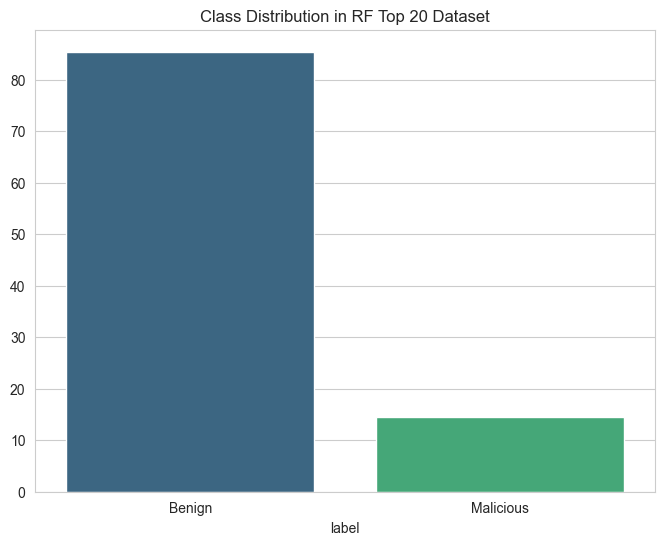

In [5]:
plt.figure(figsize=(8, 6))
sns.barplot(x=val_counts.index, y=percentages.values, palette='viridis')
plt.title('Class Distribution in RF Top 20 Dataset')

In [6]:
benign_df = rf_data[rf_data["label"] == "Benign"]
malicious_df = rf_data[rf_data["label"] == "Malicious"]

In [7]:
import random 

take_benign = 85000
take_malicious = 15000

benign_sample = benign_df.sample(n=take_benign, random_state=42)
malicious_sample = malicious_df.sample(n=take_malicious, random_state=42)

In [8]:
len(benign_sample), len(malicious_sample)

(85000, 15000)

In [9]:
sampled_rf_data = pd.concat([benign_sample, malicious_sample], ignore_index=True)
sampled_rf_data["label"].value_counts()

label
Benign       85000
Malicious    15000
Name: count, dtype: int64

In [10]:
shuffled_rf_data = sampled_rf_data.sample(frac=1, random_state=42).reset_index(drop=True)
shuffled_rf_data["label"].value_counts()

label
Benign       85000
Malicious    15000
Name: count, dtype: int64

In [11]:
X = shuffled_rf_data.drop(columns=["label"])
y = shuffled_rf_data["label"]

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [13]:
from sklearn.linear_model import LogisticRegression

log_reg_rf = LogisticRegression(max_iter=1000, random_state=42)
log_reg_rf.fit(X_train, y_train)

C:\Users\Sangam\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, random_state=42)

In [14]:
from sklearn.metrics import classification_report, confusion_matrix

In [16]:
def make_classification_report(model, X_test, y_test):
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred)
    print(report)
    
def make_confusion_matrix(model, X_test, y_test):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

In [17]:
log_reg_rf_report = make_classification_report(log_reg_rf, X_test, y_test)
print(log_reg_rf_report)

              precision    recall  f1-score   support

      Benign       0.96      0.97      0.97     17000
   Malicious       0.84      0.76      0.80      3000

    accuracy                           0.94     20000
   macro avg       0.90      0.87      0.88     20000
weighted avg       0.94      0.94      0.94     20000

None


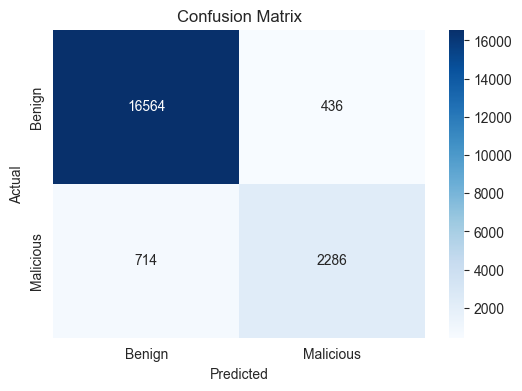

In [18]:
make_confusion_matrix(log_reg_rf, X_test, y_test)

In [19]:
preds = log_reg_rf.predict(X_test)

In [20]:
false_negatives_log_rf = set([i for i, (pred, actual) in enumerate(zip(preds, y_test)) if pred == "Benign" and actual == "Malicious"])

In [37]:
from sklearn.tree import DecisionTreeClassifier

dt_rf_model = DecisionTreeClassifier(random_state=42)
dt_rf_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [38]:
dt_rf_model.get_depth()

26

In [39]:
print(make_classification_report(dt_rf_model, X_test, y_test))

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     17000
   Malicious       0.99      0.99      0.99      3000

    accuracy                           1.00     20000
   macro avg       0.99      0.99      0.99     20000
weighted avg       1.00      1.00      1.00     20000

None


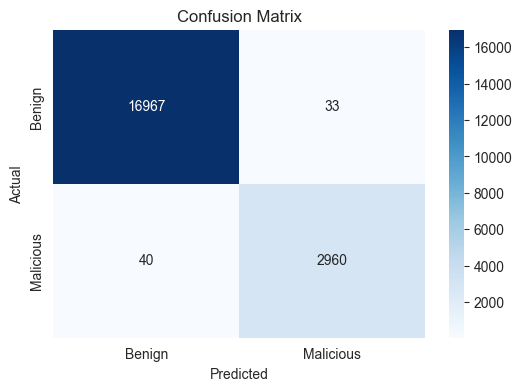

In [40]:
make_confusion_matrix(dt_rf_model, X_test, y_test)

In [41]:
dt_rf_preds = dt_rf_model.predict(X_test)
false_negatives_dt_rf = set([i for i, (pred, actual) in enumerate(zip(dt_rf_preds, y_test)) if pred == "Benign" and actual == "Malicious"])

In [42]:
common = [i for i in false_negatives_log_rf if i in false_negatives_dt_rf]

In [49]:
len(common)

35

In [43]:
from sklearn.ensemble import RandomForestClassifier

rf_rf_model = RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1)
rf_rf_model.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [44]:
print(make_classification_report(rf_rf_model, X_test, y_test))

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     17000
   Malicious       0.99      0.99      0.99      3000

    accuracy                           1.00     20000
   macro avg       1.00      0.99      0.99     20000
weighted avg       1.00      1.00      1.00     20000

None


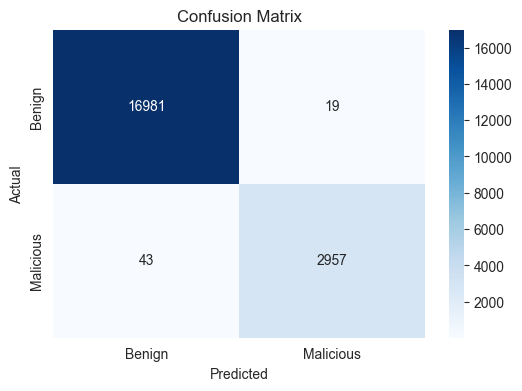

In [45]:
make_confusion_matrix(rf_rf_model, X_test, y_test)

In [46]:
rf_rf_preds = rf_rf_model.predict(X_test)
false_negatives_rf_rf = set([i for i, (pred, actual) in enumerate(zip(rf_rf_preds, y_test)) if pred == "Benign" and actual == "Malicious"])

In [47]:
common = [i for i in false_negatives_rf_rf if i in false_negatives_log_rf]

In [48]:
len(common)

34

In [31]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [5, 10, 15, 18],
    "min_samples_split": [15, 20, 25],
    "max_leaf_nodes": [50, 100],
    "criterion": ["gini", "entropy"]
    
    
}

gc = GridSearchCV(  estimator=DecisionTreeClassifier(),
                    param_grid=param_grid,
                    cv=5,
                    n_jobs=-1,
)

gc.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [5, 10, 15, 18],
                         'max_leaf_nodes': [50, 100],
                         'min_samples_split': [15, 20, 25]})

In [32]:
best_dt_rf_model = gc.best_estimator_
print(gc.best_params_)

{'criterion': 'entropy', 'max_depth': 15, 'max_leaf_nodes': 100, 'min_samples_split': 15}


In [33]:
print(make_classification_report(best_dt_rf_model, X_test, y_test))

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     17000
   Malicious       0.99      0.98      0.98      3000

    accuracy                           1.00     20000
   macro avg       0.99      0.99      0.99     20000
weighted avg       1.00      1.00      1.00     20000

None


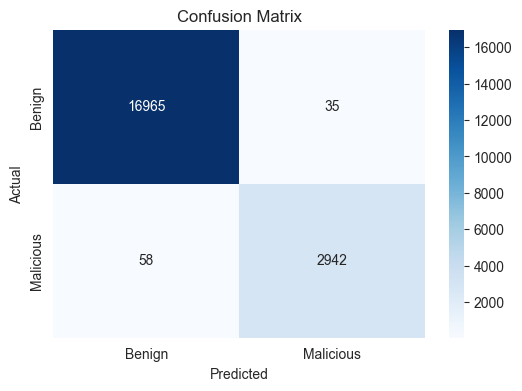

In [34]:
make_confusion_matrix(best_dt_rf_model, X_test, y_test)

In [49]:
best_dt_rf_preds = best_dt_rf_model.predict(X_test)
false_negatives_best_dt_rf = set([i for i, (pred, actual) in enumerate(zip(best_dt_rf_preds, y_test)) if pred == "Benign" and actual == "Malicious"])

In [50]:
common_dt_and_dt = set(false_negatives_dt_rf) & set(false_negatives_best_dt_rf)


In [51]:
common_dt_and_log = set(false_negatives_log_rf) & set(false_negatives_best_dt_rf)

In [52]:
len(common_dt_and_dt), len(common_dt_and_log)

(34, 45)

In [22]:
class_weights = {
    "Benign": 1,
    "Malicious": 5
}

param_grid_weighted = {
    "max_depth": [5, 10, 15],
    "min_samples_split": [15, 20, 25],
    "max_leaf_nodes": [50, 100],
    "criterion": ["gini", "entropy"],
    "class_weight": [class_weights]
}

In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

cv_class_weights = GridSearchCV(estimator=DecisionTreeClassifier(class_weight=class_weights),
                    param_grid=param_grid_weighted,
                    cv=5,
                    n_jobs=-1
)

cv_class_weights.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=DecisionTreeClassifier(class_weight={'Benign': 1,
                                                            'Malicious': 5}),
             n_jobs=-1,
             param_grid={'class_weight': [{'Benign': 1, 'Malicious': 5}],
                         'criterion': ['gini', 'entropy'],
                         'max_depth': [5, 10, 15], 'max_leaf_nodes': [50, 100],
                         'min_samples_split': [15, 20, 25]})

In [26]:
best_dt_rf_class_weight_model = cv_class_weights.best_estimator_
print(cv_class_weights.best_params_)

{'class_weight': {'Benign': 1, 'Malicious': 5}, 'criterion': 'entropy', 'max_depth': 15, 'max_leaf_nodes': 100, 'min_samples_split': 25}


In [27]:
print(make_classification_report(best_dt_rf_class_weight_model, X_test, y_test))

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     17000
   Malicious       0.97      0.99      0.98      3000

    accuracy                           0.99     20000
   macro avg       0.99      0.99      0.99     20000
weighted avg       0.99      0.99      0.99     20000

None


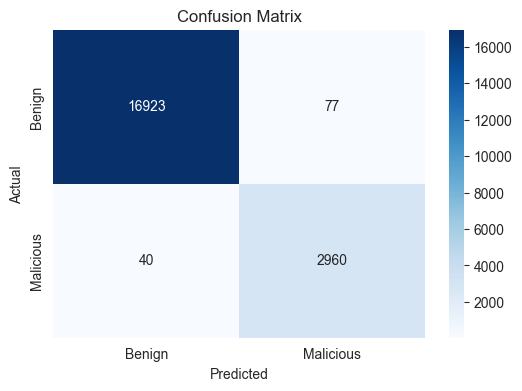

In [28]:
make_confusion_matrix(best_dt_rf_class_weight_model, X_test, y_test)

In [29]:
best_dt_rf_class_weight_preds = best_dt_rf_class_weight_model.predict(X_test)
false_negatives_best_dt_rf_class_weight = set([i for i, (pred, actual) in enumerate(zip(best_dt_rf_class_weight_preds, y_test)) if pred == "Benign" and actual == "Malicious"])

In [53]:
common_dt_and_dt_class_weight = false_negatives_best_dt_rf_class_weight & false_negatives_dt_rf

In [54]:
common_log_and_dt_class_weight = false_negatives_best_dt_rf_class_weight & false_negatives_log_rf

In [55]:
len(common_dt_and_dt_class_weight), len(common_log_and_dt_class_weight)

(26, 29)

In [56]:
feature_importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_dt_rf_class_weight_model.feature_importances_
}).sort_values(by="importance", ascending=False)

C:\Users\Sangam\AppData\Local\Temp\ipykernel_6972\277960067.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importance", y="feature", data=feature_importances, palette='viridis')


Text(0.5, 0, 'Importance')

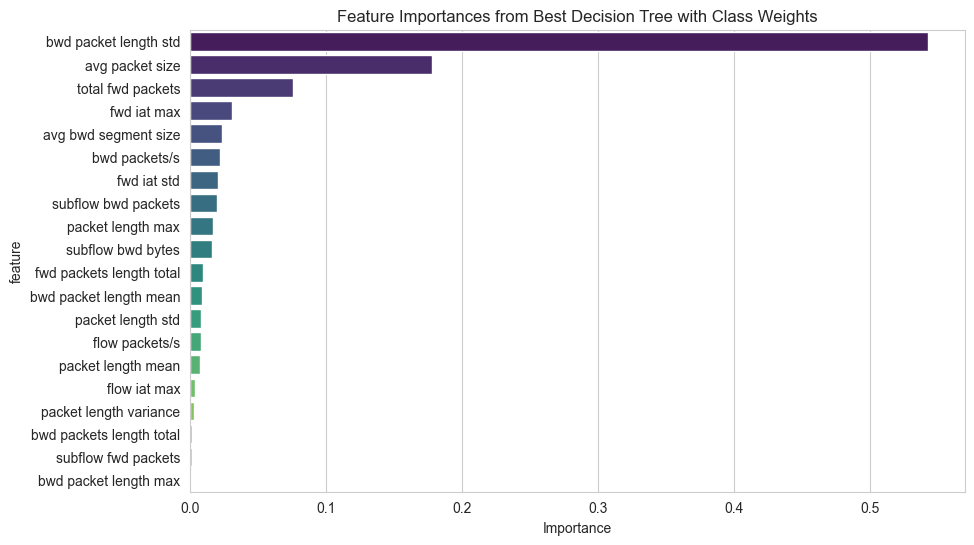

In [57]:
plt.figure(figsize=(10, 6))
sns.barplot(x="importance", y="feature", data=feature_importances, palette='viridis')
plt.title('Feature Importances from Best Decision Tree with Class Weights')
plt.xlabel('Importance')

In [58]:
top_10_features = feature_importances.head(10)
features = top_10_features["feature"].tolist()

In [60]:
new_features_cv = GridSearchCV(estimator=DecisionTreeClassifier(class_weight=class_weights),
                    param_grid=param_grid_weighted,
                    cv=5,
                    n_jobs=-1
)


new_features_cv.fit(X_train[features], y_train)

GridSearchCV(cv=5,
             estimator=DecisionTreeClassifier(class_weight={'Benign': 1,
                                                            'Malicious': 5}),
             n_jobs=-1,
             param_grid={'class_weight': [{'Benign': 1, 'Malicious': 5}],
                         'criterion': ['gini', 'entropy'],
                         'max_depth': [5, 10, 15], 'max_leaf_nodes': [50, 100],
                         'min_samples_split': [15, 20, 25]})

In [61]:
new_features_dt_cv_model = new_features_cv.best_estimator_
print(new_features_cv.best_params_)

{'class_weight': {'Benign': 1, 'Malicious': 5}, 'criterion': 'entropy', 'max_depth': 15, 'max_leaf_nodes': 100, 'min_samples_split': 15}


In [62]:
print(make_classification_report(new_features_dt_cv_model, X_test[features], y_test))

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     17000
   Malicious       0.98      0.98      0.98      3000

    accuracy                           0.99     20000
   macro avg       0.99      0.99      0.99     20000
weighted avg       0.99      0.99      0.99     20000

None


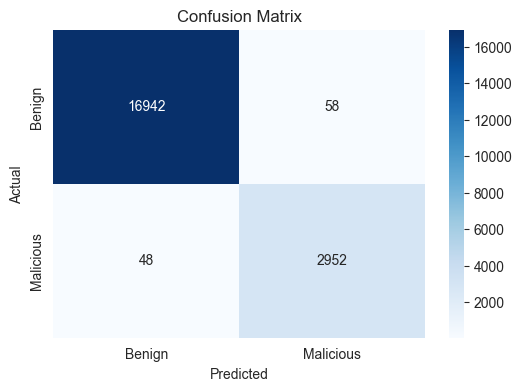

In [63]:
make_confusion_matrix(new_features_dt_cv_model, X_test[features], y_test)

In [64]:
new_features_dt_cv_preds = new_features_dt_cv_model.predict(X_test[features])
false_negatives_new_features_dt_cv = set([i for i, (pred, actual) in enumerate(zip(new_features_dt_cv_preds, y_test)) if pred == "Benign" and actual == "Malicious"])

In [65]:
common_new_features_and_dt = false_negatives_new_features_dt_cv & false_negatives_best_dt_rf

In [66]:
common_new_features_and_log = false_negatives_new_features_dt_cv & false_negatives_log_rf

In [67]:
len(common_new_features_and_dt), len(common_new_features_and_log)

(41, 36)

In [68]:
corr = X_train[features].corr()

Text(0.5, 1.0, 'Correlation Matrix of Top 10 Features')

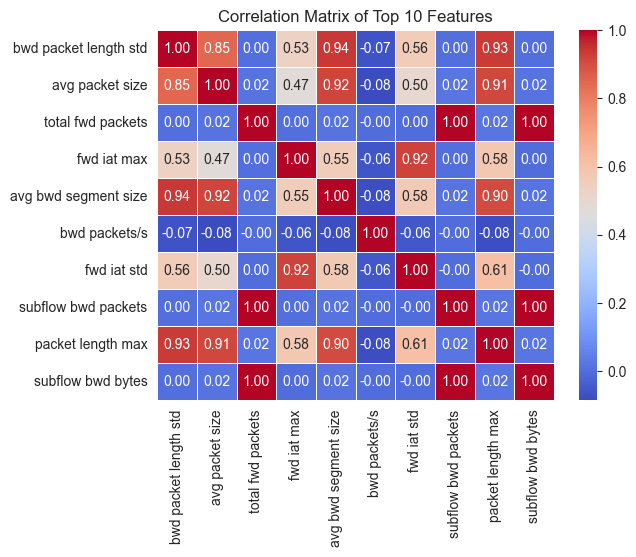

In [69]:
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Top 10 Features')

In [124]:
new_selected_features = [
    "total fwd packets", "bwd packet length std", "avg packet size", "bwd packets/s"
]

In [150]:
final_tree = DecisionTreeClassifier(random_state=42, class_weight=class_weights, max_depth=10, min_samples_split=15, max_leaf_nodes=100, criterion="gini")

final_tree.fit(X_train[new_selected_features], y_train)

DecisionTreeClassifier(class_weight={'Benign': 1, 'Malicious': 5}, max_depth=10,
                       max_leaf_nodes=100, min_samples_split=15,
                       random_state=42)

In [151]:
print(make_classification_report(final_tree, X_test[new_selected_features], y_test))

              precision    recall  f1-score   support

      Benign       1.00      0.99      0.99     17000
   Malicious       0.95      0.98      0.96      3000

    accuracy                           0.99     20000
   macro avg       0.97      0.98      0.98     20000
weighted avg       0.99      0.99      0.99     20000

None


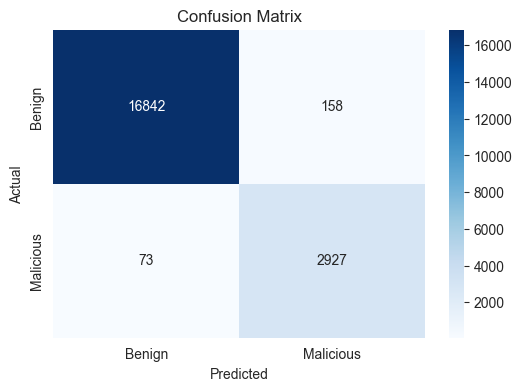

In [152]:
make_confusion_matrix(final_tree, X_test[new_selected_features], y_test)

In [153]:
final_tree_preds = final_tree.predict(X_test[new_selected_features])
false_negatives_final_tree = set([i for i, (pred, actual) in enumerate(zip(final_tree_preds, y_test)) if pred == "Benign" and actual == "Malicious"])

In [154]:
common_final_and_dt = false_negatives_final_tree & false_negatives_best_dt_rf
common_final_and_log = false_negatives_final_tree & false_negatives_log_rf

In [155]:
len(common_final_and_dt), len(common_final_and_log)

(50, 60)

In [156]:
import pickle 

with open("../../Models/final_decision_tree_rf_model.pkl", "wb") as f:
    pickle.dump(final_tree, f)

In [78]:
from sklearn.decomposition import PCA 

pca = PCA(n_components=8, random_state=42)

pca.fit(X_train)

PCA(n_components=8, random_state=42)

In [79]:
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

In [80]:
pca_dt_model = DecisionTreeClassifier(random_state=42, class_weight=class_weights, max_depth=18, min_samples_split=15, max_leaf_nodes=100, criterion="gini") 
pca_dt_model.fit(X_train_pca, y_train)

DecisionTreeClassifier(class_weight={'Benign': 1, 'Malicious': 5}, max_depth=18,
                       max_leaf_nodes=100, min_samples_split=15,
                       random_state=42)

In [81]:
print(make_classification_report(pca_dt_model, X_test_pca, y_test))

              precision    recall  f1-score   support

      Benign       1.00      0.99      0.99     17000
   Malicious       0.94      0.97      0.96      3000

    accuracy                           0.99     20000
   macro avg       0.97      0.98      0.97     20000
weighted avg       0.99      0.99      0.99     20000

None


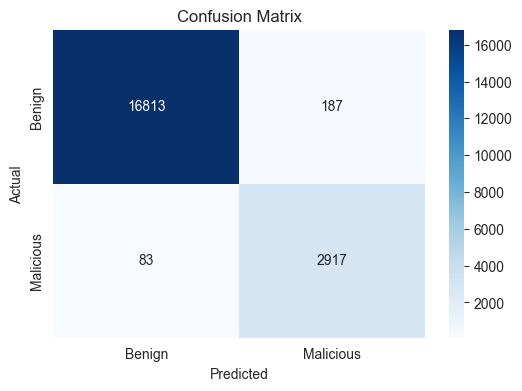

In [82]:
make_confusion_matrix(pca_dt_model, X_test_pca, y_test)

In [83]:
pca_2 = PCA(n_components=10, random_state=42)
pca_2.fit(X_train)

PCA(n_components=10, random_state=42)

In [95]:
X_train_pca = pca_2.transform(X_train)
X_test_pca = pca_2.transform(X_test)

In [96]:
dt_pca_2_model = DecisionTreeClassifier(random_state=42, class_weight=class_weights, max_depth=18, min_samples_split=15, max_leaf_nodes=100, criterion="gini")
dt_pca_2_model.fit(X_train_pca, y_train)

DecisionTreeClassifier(class_weight={'Benign': 1, 'Malicious': 5}, max_depth=18,
                       max_leaf_nodes=100, min_samples_split=15,
                       random_state=42)

In [97]:
print(make_classification_report(dt_pca_2_model, X_test_pca, y_test))

              precision    recall  f1-score   support

      Benign       1.00      0.99      0.99     17000
   Malicious       0.94      0.97      0.95      3000

    accuracy                           0.99     20000
   macro avg       0.97      0.98      0.97     20000
weighted avg       0.99      0.99      0.99     20000

None


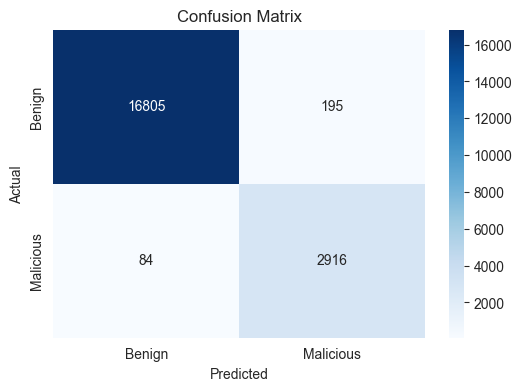

In [98]:
make_confusion_matrix(dt_pca_2_model, X_test_pca, y_test)

In [118]:
X_top_10 = X[features]
X_train_top_10, X_test_top_10, y_train_top_10, y_test_top_10 = train_test_split(X_top_10, y, test_size=0.2, random_state=42, stratify=y)

In [119]:
pca_3 = PCA(n_components=8, random_state=42)
pca_3.fit(X_train_top_10)

PCA(n_components=8, random_state=42)

In [120]:
X_train_pca = pca_3.transform(X_train_top_10)
X_test_pca = pca_3.transform(X_test_top_10)

In [121]:
pca_dt_model_3 = DecisionTreeClassifier(random_state=42, class_weight=class_weights, max_depth=18, min_samples_split=15, max_leaf_nodes=100, criterion="gini")
pca_dt_model_3.fit(X_train_pca, y_train)

DecisionTreeClassifier(class_weight={'Benign': 1, 'Malicious': 5}, max_depth=18,
                       max_leaf_nodes=100, min_samples_split=15,
                       random_state=42)

In [122]:
print(make_classification_report(pca_dt_model_3, X_test_pca, y_test_top_10))

              precision    recall  f1-score   support

      Benign       1.00      0.99      0.99     17000
   Malicious       0.96      0.98      0.97      3000

    accuracy                           0.99     20000
   macro avg       0.98      0.99      0.98     20000
weighted avg       0.99      0.99      0.99     20000

None


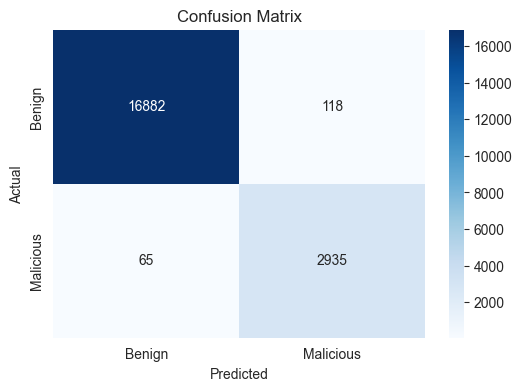

In [123]:
make_confusion_matrix(pca_dt_model_3, X_test_pca, y_test_top_10)